# High Frequency Words

**Author:** Sabina Baraili

For this assignment, I used *Pride and Prejudice* by Jane Austen as the corpus. The text comes from Project Gutenberg and is saved locally in this folder so the notebook can be rerun without changing the source.

## Overview

This notebook answers each part of the assignment in order. I included short explanations of what I am doing and why, because the final counts depend on how the text is cleaned and how a word is defined. For this notebook, I treat a word as a lowercase alphabetic token and keep apostrophes only when they appear inside a contraction.

## 1. Choose a corpus of interest

I chose *Pride and Prejudice* because it is a well-known novel with enough text to show a clear frequency pattern. It also has both narration and dialogue, so the word distribution is more interesting than it would be in a very short or narrow text.

## Method

The first step is to import the tools needed for the analysis. I use `Path` to read the local text file, `re` to break the text into word tokens, `Counter` to count how often each word appears, `csv` to save the top-200 list, and `matplotlib` to create the graphs. These tools are enough for a clear and reproducible analysis without adding extra complexity.

In [1]:
from pathlib import Path
import re
from collections import Counter
import csv
import math

import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

## Preparing the Corpus

Before counting words, I remove the Project Gutenberg header and footer so the analysis focuses on the novel itself instead of the license material. I then convert the text to lowercase and use a regular expression to extract words. This step matters because punctuation, capitalization, and contractions can all affect both the total count and the number of unique words.

In [2]:
raw_text = Path('data/pride_and_prejudice_raw.txt').read_text(encoding='utf-8')

start_marker = '*** START OF THE PROJECT GUTENBERG EBOOK PRIDE AND PREJUDICE ***'
end_marker = '*** END OF THE PROJECT GUTENBERG EBOOK PRIDE AND PREJUDICE ***'

start = raw_text.find(start_marker)
end = raw_text.find(end_marker)

if start != -1 and end != -1:
    text = raw_text[start + len(start_marker):end]
else:
    text = raw_text

text = text.replace('\ufeff', '')

# I define words as lowercase alphabetic tokens and keep apostrophes in contractions.
tokens = re.findall(r"[a-z]+(?:'[a-z]+)?", text.lower())
word_counts = Counter(tokens)
top_200 = word_counts.most_common(200)

total_words = len(tokens)
unique_words = len(word_counts)

total_words, unique_words

(128565, 6729)

## 2. How many total unique words are in the corpus?

I defined a word as a lowercase alphabetic token, with punctuation removed and apostrophes kept in contractions. Using that definition, the corpus contains **128,565 total word tokens** and **6,729 unique words**.

In [3]:
total_words, unique_words

(128565, 6729)

The output above gives two useful baseline numbers. `total_words` is the total number of word occurrences in the novel, while `unique_words` is the number of distinct words under my definition. This matters because a book can repeat a small set of common words many times while still containing a much larger vocabulary overall.

## 3. Taking the most common words, how many unique words represent half of the total words in the corpus?

## Why Calculate the Halfway Point?

This step shows how concentrated the vocabulary is. Instead of only asking which words are common, it asks how many different words are needed to account for half of all word use in the novel. If that number is small, then the text is being driven by a short list of very common words.

In [4]:
half_total = total_words / 2
running_total = 0
words_needed_for_half = 0

for word, count in word_counts.most_common():
    running_total += count
    words_needed_for_half += 1
    if running_total >= half_total:
        break

words_needed_for_half, running_total, half_total

(58, 64432, 64282.5)

The result shows that **58 unique words** account for at least half of all word occurrences in the novel. In other words, fewer than 60 words make up 50% of the corpus. That is a strong sign that a small high-frequency vocabulary carries a large share of the text.

## 4. Identify the 200 highest frequency words in this corpus

## Why List the Top 200 Words?

The assignment asks for the 200 highest-frequency words, but this list also helps interpret the corpus. It shows which common function words dominate the text and which content words or character names start to stand out. Saving the list to a CSV file also makes it easy to review the results outside the notebook.

In [5]:
output_path = Path('data/top_200_words.csv')
with output_path.open('w', newline='', encoding='utf-8') as f:
    writer = csv.writer(f)
    writer.writerow(['rank', 'word', 'count', 'relative_frequency'])
    for rank, (word, count) in enumerate(top_200, start=1):
        writer.writerow([rank, word, count, count / total_words])

for rank, (word, count) in enumerate(top_200, start=1):
    print(f'{rank:>3}. {word:<15} {count}')

print(f'\nSaved full list to: {output_path}')

  1. the             4663
  2. to              4325
  3. of              3844
  4. and             3767
  5. her             2284
  6. i               2122
  7. a               2038
  8. in              1994
  9. was             1875
 10. she             1751
 11. that            1646
 12. it              1590
 13. not             1500
 14. you             1376
 15. he              1358
 16. his             1303
 17. be              1264
 18. as              1229
 19. had             1186
 20. with            1103
 21. for             1096
 22. but             1038
 23. is              926
 24. have            879
 25. at              816
 26. mr              808
 27. him             777
 28. on              734
 29. my              728
 30. by              699
 31. s               672
 32. all             651
 33. elizabeth       645
 34. they            610
 35. so              607
 36. were            570
 37. which           568
 38. been            536
 39. could           531
 40

The top of the list is dominated by very common function words such as `the`, `to`, `of`, and `and`, which is typical of natural language. The list also begins to show words that are more specific to this corpus, including names and terms tied to the social world of the novel.

## 5. Graph of the relative frequency of the top 200 words

The graph below shows how relative frequency changes as word rank moves from 1 to 200. I used a clearer line chart so the overall pattern is easier to read than it would be with 200 narrow bars.

## Why This Graph?

A graph makes the distribution easier to understand than a table alone. The main goal here is to show how sharply frequency falls from the most common word to the 200th most common word. That decline is important because natural language usually has a few very common words followed by many much rarer ones.

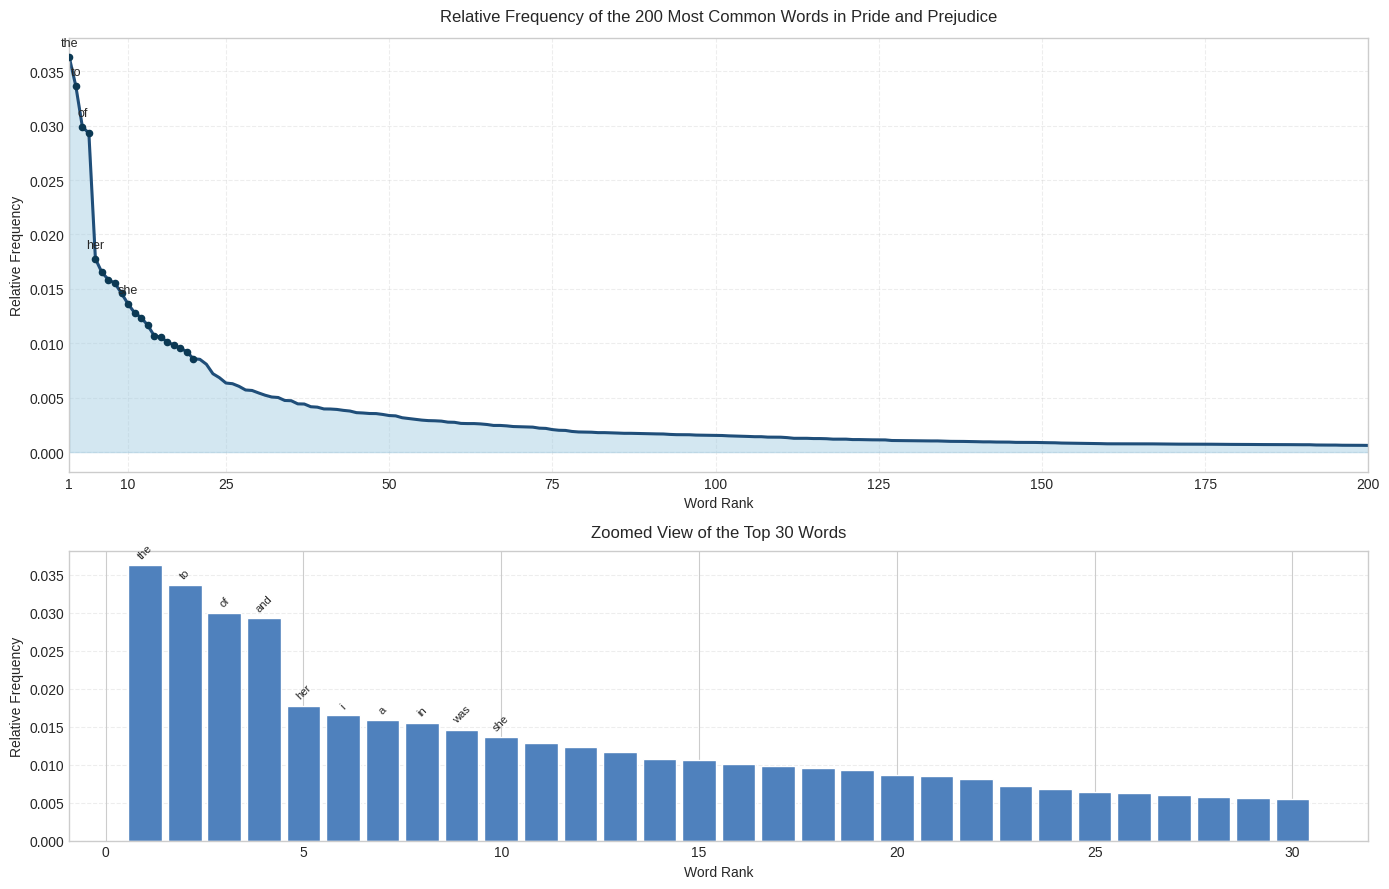

In [6]:
ranks = list(range(1, 201))
relative_frequencies = [count / total_words for _, count in top_200]
words_for_labels = [word for word, _ in top_200]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 9), height_ratios=[3, 2])

ax1.plot(ranks, relative_frequencies, color='#1f4e79', linewidth=2.2)
ax1.fill_between(ranks, relative_frequencies, color='#9ecae1', alpha=0.45)
ax1.scatter(ranks[:20], relative_frequencies[:20], color='#0b3954', s=20, zorder=3)
ax1.set_title('Relative Frequency of the 200 Most Common Words in Pride and Prejudice', pad=12)
ax1.set_xlabel('Word Rank')
ax1.set_ylabel('Relative Frequency')
ax1.set_xlim(1, 200)
ax1.set_xticks([1, 10, 25, 50, 75, 100, 125, 150, 175, 200])
ax1.grid(True, linestyle='--', alpha=0.35)

for idx in [0, 1, 2, 4, 9]:
    ax1.annotate(words_for_labels[idx], (ranks[idx], relative_frequencies[idx]),
                 textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

ax2.bar(ranks[:30], relative_frequencies[:30], color='#4f81bd', edgecolor='white', width=0.85)
ax2.set_title('Zoomed View of the Top 30 Words', pad=10)
ax2.set_xlabel('Word Rank')
ax2.set_ylabel('Relative Frequency')
ax2.grid(True, axis='y', linestyle='--', alpha=0.35)

for idx in range(10):
    ax2.annotate(words_for_labels[idx], (ranks[idx], relative_frequencies[idx]),
                 textcoords='offset points', xytext=(0, 5), ha='center', fontsize=8, rotation=45)

fig.tight_layout()
fig.savefig('figures/top_200_relative_frequency_v004.png', dpi=200, bbox_inches='tight')
plt.show()

## 6. Does the observed relative frequency of these words follow Zipf's law?

## Why Use a Zipf Plot?

Zipf's law says that word frequency is often roughly inversely related to rank, so a log-log plot is a standard way to check that pattern. I compare the observed frequencies with a simple `1/r` reference line to see whether the novel follows the expected trend.

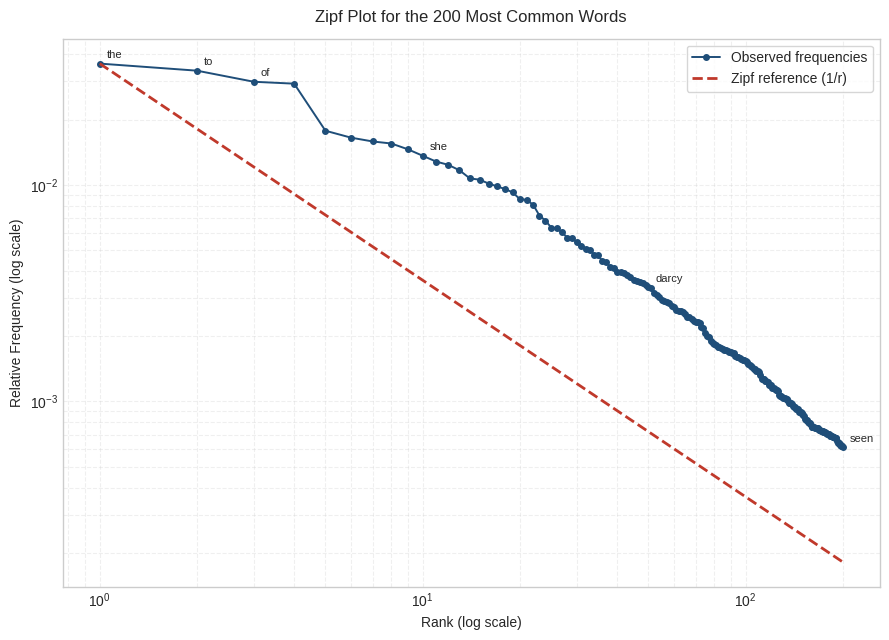

In [7]:
zipf_reference = [relative_frequencies[0] / rank for rank in ranks]

fig, ax = plt.subplots(figsize=(9, 6.5))
ax.loglog(ranks, relative_frequencies, marker='o', linestyle='-', linewidth=1.4, markersize=4, color='#1f4e79', label='Observed frequencies')
ax.loglog(ranks, zipf_reference, linestyle='--', color='#c0392b', linewidth=2.0, label='Zipf reference (1/r)')
ax.set_title('Zipf Plot for the 200 Most Common Words', pad=12)
ax.set_xlabel('Rank (log scale)')
ax.set_ylabel('Relative Frequency (log scale)')
ax.grid(True, which='both', linestyle='--', alpha=0.3)
ax.legend(frameon=True)

for idx in [0, 1, 2, 9, 49, 199]:
    ax.annotate(words_for_labels[idx], (ranks[idx], relative_frequencies[idx]),
                textcoords='offset points', xytext=(5, 4), fontsize=8)

fig.tight_layout()
fig.savefig('figures/zipf_plot_v004.png', dpi=200, bbox_inches='tight')
plt.show()

The observed relative frequencies follow Zipf's law reasonably well. The most common words are much more frequent than the rest, and the drop-off is steep as rank increases. On the log-log plot, the observed points stay fairly close to the reference line for much of the range, so the overall pattern is consistent with Zipf-like behavior even though the fit is not perfect.

## 7. How does this corpus differ from all words in all corpora?

This corpus is a single nineteenth-century English novel, so its word frequencies reflect that genre, author, and time period rather than language in general.

- It contains many dialogue-heavy words such as pronouns and common verbs.
- It overrepresents topics central to the novel, especially family relationships, class, manners, and marriage.
- Character names such as `elizabeth`, `darcy`, `jane`, `bennet`, and `bingley` appear much more often than they would in a broad multi-domain corpus.
- Its vocabulary is literary and historical, so it differs from modern sources such as news, academic writing, or web text.

Because of that, the corpus still shows the general Zipf pattern, but the actual high-frequency words are shaped by the subject matter and style of this novel.